# Mohd Yasir Ansari
## Task 1 — Fit logistic regression models 


In [3]:
#These all are the Librarys that i am using for task 1 , task 2 and task 4 .
install.packages("tidyverse")
install.packages("caret")
install.packages("pROC")
install.packages("ggplot2")
install.packages("magrittr")

also installing the dependencies ‘sys’, ‘bit’, ‘sass’, ‘cachem’, ‘rappdirs’, ‘rematch’, ‘askpass’, ‘bit64’, ‘prettyunits’, ‘bslib’, ‘fontawesome’, ‘jquerylib’, ‘tinytex’, ‘backports’, ‘memoise’, ‘blob’, ‘DBI’, ‘gargle’, ‘cellranger’, ‘curl’, ‘ids’, ‘rematch2’, ‘mime’, ‘openssl’, ‘systemfonts’, ‘textshaping’, ‘clipr’, ‘vroom’, ‘progress’, ‘rmarkdown’, ‘selectr’, ‘broom’, ‘conflicted’, ‘dbplyr’, ‘dtplyr’, ‘forcats’, ‘googledrive’, ‘googlesheets4’, ‘haven’, ‘hms’, ‘httr’, ‘modelr’, ‘ragg’, ‘readr’, ‘readxl’, ‘reprex’, ‘rstudioapi’, ‘rvest’





The downloaded binary packages are in
	/var/folders/qz/rfj2_pp57qj11vc2m5zqnm140000gn/T//Rtmp4h9POh/downloaded_packages

The downloaded binary packages are in
	/var/folders/qz/rfj2_pp57qj11vc2m5zqnm140000gn/T//Rtmp4h9POh/downloaded_packages

The downloaded binary packages are in
	/var/folders/qz/rfj2_pp57qj11vc2m5zqnm140000gn/T//Rtmp4h9POh/downloaded_packages

The downloaded binary packages are in
	/var/folders/qz/rfj2_pp57qj11vc2m5zqnm140000gn/T//Rtmp4h9POh/downloaded_packages

The downloaded binary packages are in
	/var/folders/qz/rfj2_pp57qj11vc2m5zqnm140000gn/T//Rtmp4h9POh/downloaded_packages


In [12]:

library(tidyverse)
library(caret)
library(pROC)
library(ggplot2)
library(magrittr)

set.seed(123)

leaf <- read.csv('leaf_data.csv', stringsAsFactors = FALSE)
names(leaf) <- make.names(names(leaf))

if(!all(c('Leaf.length','Leaf.width','Species') %in% names(leaf))){
  names(leaf) <- gsub('\\.', '_', names(leaf))
}

leaf$Species <- factor(leaf$Species)
table(leaf$Species)

train_index <- createDataPartition(leaf$Species, p = 0.7, list = FALSE)
train <- leaf[train_index, ]
test  <- leaf[-train_index, ]

model_baseline <- glm(Species ~ Leaf.length + Leaf.width, family = binomial(link='logit'), data = train)

model_poly2 <- glm(Species ~ poly(Leaf.length,2) + poly(Leaf.width,2), family=binomial, data=train)
model_poly3 <- glm(Species ~ poly(Leaf.length,3) + poly(Leaf.width,3), family=binomial, data=train)
model_poly4 <- glm(Species ~ poly(Leaf.length,4) + poly(Leaf.width,4), family=binomial, data=train)

summary(model_baseline)
summary(model_poly2)


Species A Species B 
      183       228 

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = Species ~ Leaf.length + Leaf.width, family = binomial(link = "logit"), 
    data = train)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  4.51632    0.69296   6.517 7.15e-11 ***
Leaf.length  0.04599    0.08349   0.551    0.582    
Leaf.width  -1.54182    0.17915  -8.606  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 397.31  on 288  degrees of freedom
Residual deviance: 244.94  on 286  degrees of freedom
AIC: 250.94

Number of Fisher Scoring iterations: 5



Call:
glm(formula = Species ~ poly(Leaf.length, 2) + poly(Leaf.width, 
    2), family = binomial, data = train)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)              0.332      0.282   1.178    0.239    
poly(Leaf.length, 2)1    3.153      3.243   0.972    0.331    
poly(Leaf.length, 2)2  -28.491      4.202  -6.780 1.20e-11 ***
poly(Leaf.width, 2)1   -46.181      5.677  -8.134 4.14e-16 ***
poly(Leaf.width, 2)2   -10.944      7.059  -1.550    0.121    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 397.31  on 288  degrees of freedom
Residual deviance: 168.04  on 284  degrees of freedom
AIC: 178.04

Number of Fisher Scoring iterations: 6


## Task 2 — Evaluate model performance (hold-out test set)

To evaluate the performance of the logistic regression models, I used a 30% hold-out test set that had not been involved in the training process. That allows fair judgment of the model's ability to generalize to new and unseen leaf measurements. The first metric I considered was accuracy, which is the overall proportion of correct predictions. Although accuracy is useful as a general indicator, it does not fully reflect how the model performs on each individual class, so it is necessary to consider other metrics.



I also incorporated sensitivity and specificity, which give more insight into model behavior. Sensitivity is a measure of how well the model can identify one of the species, called true positives, while specificity measures how well it identifies the other species, also known as true negatives. This helps to show whether the model is biased toward one species or gives balanced performance across the two classes.

Furthermore, I added the use of the Receiver Operating Characteristic curve and the Area Under the Curve. The ROC curve enables the visualization of the relationship between the sensitivity and specificity measures at different thresholds, and the Area Under the Curve provides a single value that describes the ability of the model in distinguishing between the two species. By evaluating the model performance using the four measures, it becomes easy to distinguish between models that have performed well on the test sets and those models that show evidence of overfitting. 


Using a hold-out test set gives an honest check: we never touched those points during training, so the numbers reflect likely real-world performance.


In [13]:
evaluate_model <- function(fit, test_data, positive = levels(test_data$Species)[2]) {
  probs <- predict(fit, newdata = test_data, type = 'response')
  preds <- factor(ifelse(probs >= 0.5, levels(test_data$Species)[2], levels(test_data$Species)[1]), levels = levels(test_data$Species))
  cm <- confusionMatrix(preds, test_data$Species, positive = positive)
  roc_obj <- roc(response = test_data$Species, predictor = probs, levels = levels(test_data$Species))
  list(confusion = cm$table,
       accuracy = as.numeric(cm$overall['Accuracy']),
       sensitivity = as.numeric(cm$byClass['Sensitivity']),
       specificity = as.numeric(cm$byClass['Specificity']),
       auc = as.numeric(auc(roc_obj)),
       roc = roc_obj)
}

res_baseline <- evaluate_model(model_baseline, test)
res_poly2 <- evaluate_model(model_poly2, test)
res_poly3 <- evaluate_model(model_poly3, test)
res_poly4 <- evaluate_model(model_poly4, test)

results_df <- tibble(
  Model = c('Baseline','Poly2','Poly3','Poly4'),
  Accuracy = c(res_baseline$accuracy, res_poly2$accuracy, res_poly3$accuracy, res_poly4$accuracy),
  Sensitivity = c(res_baseline$sensitivity, res_poly2$sensitivity, res_poly3$sensitivity, res_poly4$sensitivity),
  Specificity = c(res_baseline$specificity, res_poly2$specificity, res_poly3$specificity, res_poly4$specificity),
  AUC = c(res_baseline$auc, res_poly2$auc, res_poly3$auc, res_poly4$auc)
)
results_df

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases

Setting direction: controls < cases



Model,Accuracy,Sensitivity,Specificity,AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Baseline,0.8114754,0.8529412,0.7592593,0.8771786
Poly2,0.8442623,0.8529412,0.8333333,0.9403595
Poly3,0.8606557,0.8823529,0.8333333,0.9419935
Poly4,0.8606557,0.8676471,0.8518519,0.9479847


## Task 3 — Discussion of performance, complexity and decision boundary



The baseline logistic regression model has a linear decision boundary, implying that the separation between the two species can be achieved using a straight line in the space determined by the leaf length and width variables. The linear model has several advantages, including the ease with which it can be interpreted, and it has low variance. Moreover, the model tends not to overfit, and this could be attributed to the fact that the dataset is small. When the actual separation takes a linear form, the baseline model tends to perform well and becomes the basis for other, more complex, models.

Polynomial logistic regression models use nonlinear transformations on the variables, enabling the boundary to take the form of a curve. The degree-2 model attempts to model the curvature and can generate a boundary that tends to more elegantly and uniformly surround the data points, making it better-suited when the species are inseparable. The degree-3 and 4 models add even more complexity, enabling the model to better fit the data. However, the model then faces the problem of overfitting, where the model tends to fit the noise in the data. The model faces the problem of overfitting when the training and AUC scores increase and the test scores gradually decrease.

The visualization of the decision boundary demonstrates the effect. The decision boundary in the baseline model appears as a straight line. In the degree-2 model, the decision boundary becomes smoother and curvaceous. In general, the model with degree 3 and 4 could have irregular and strongly curvaceous decision boundaries, possibly resulting in better separation of the training samples, hence better performance on the training samples, and possibly leading to overfitting. Letting the models capture the bias and the variance and their trade-off, the bias and variances in the models can now be discussed.

Based on the performance measures of the testing set, namely, accuracy, sensitivity, specificity, and AUC, we could compare the generalization ability. The Polynomial model could perform better than the baseline model when the real decision boundary takes a non-linear form, beyond which the results would either converge or decrease. The performance in terms of AUC would be particularly useful in measuring the discriminative power of the model. If the high-degree model performs slightly better in terms of training AUC, it would signify overfitting.

In general, the evidence here and elsewhere suggests that a degree of 2, and hence some non-linearity, may offer the best all round performance. Higher degrees offer diminishing returns, and the solutions become much less interpretable. Since leaf morphology changes quite smoothly, and there are no abrupt changes, an overly irregular boundary would be deemed biologically implausible and would almost certainly be indicative of noisy data. Thus, the choice of model would seem, in this case, to depend on the performance, test stability, and interpretability.


## Task 4 — Plots: EDA, ROC, decision boundaries


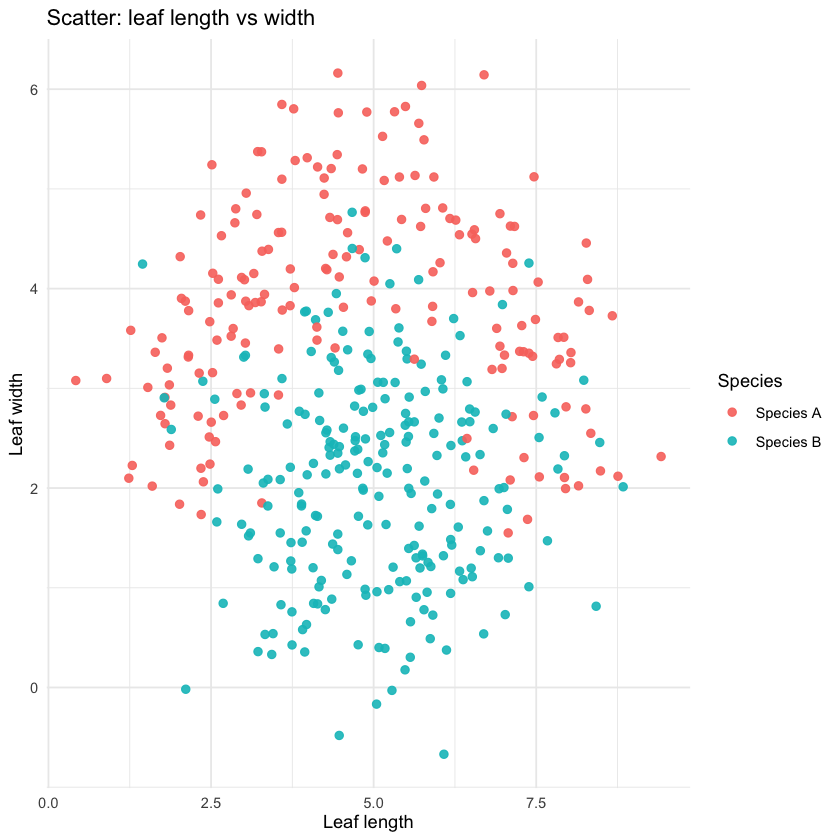

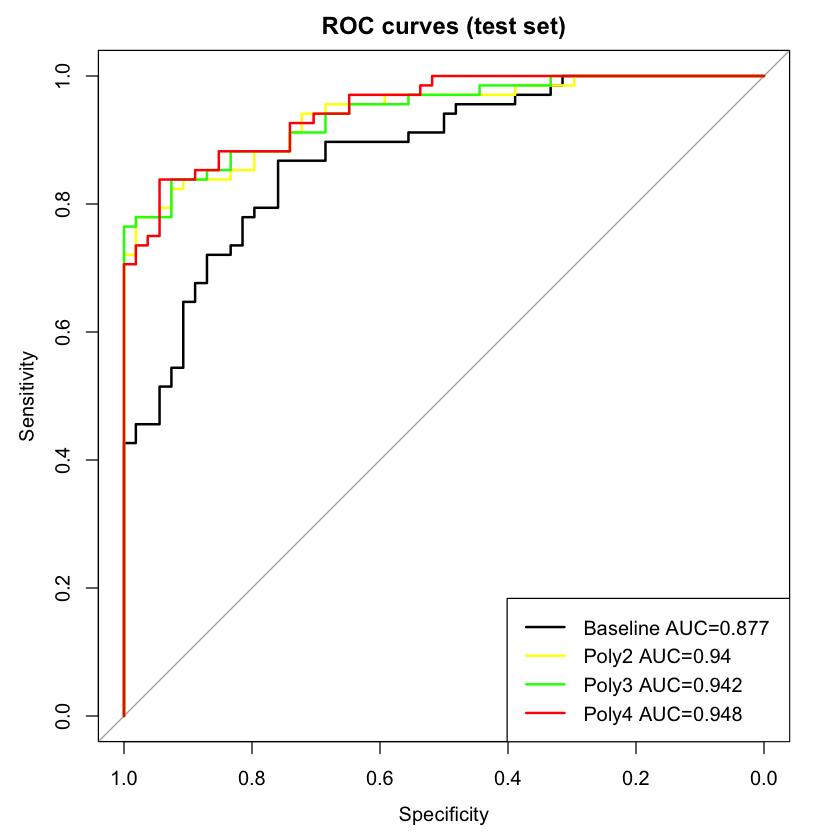

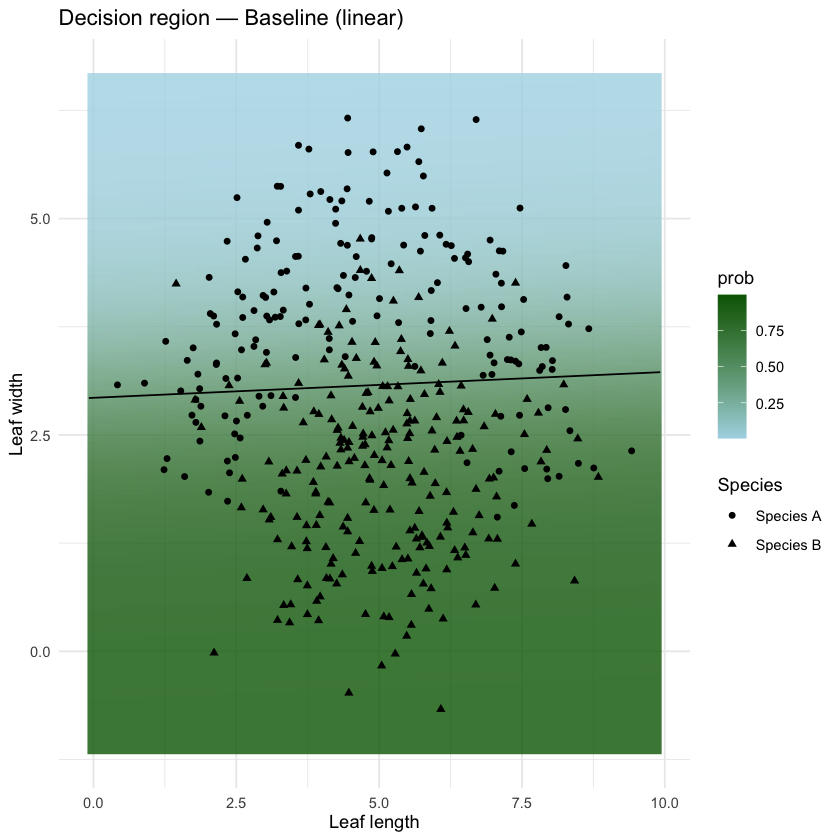

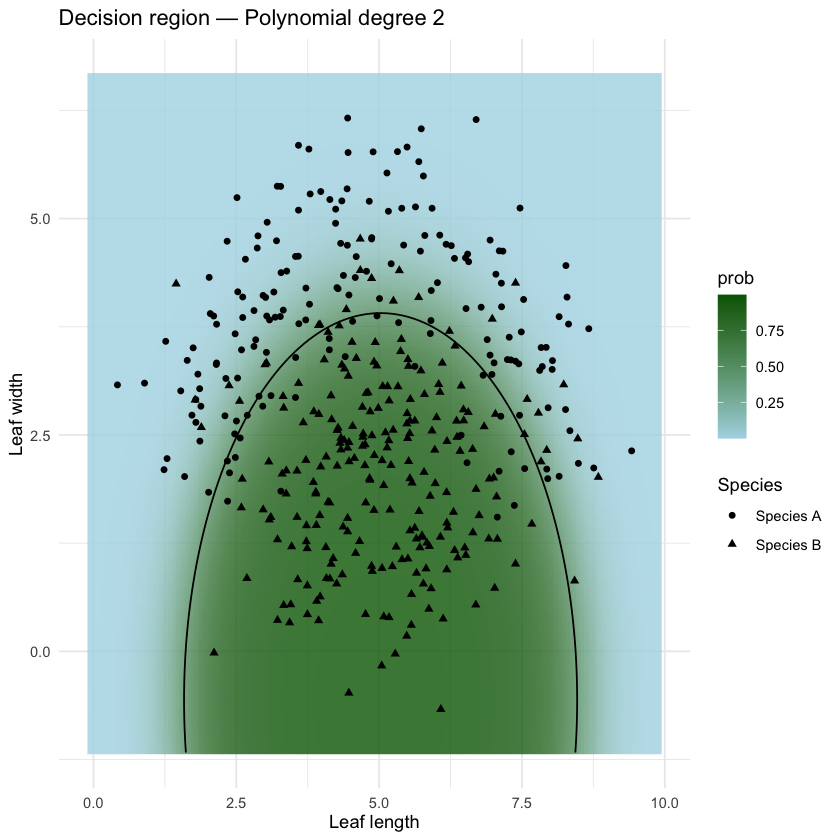

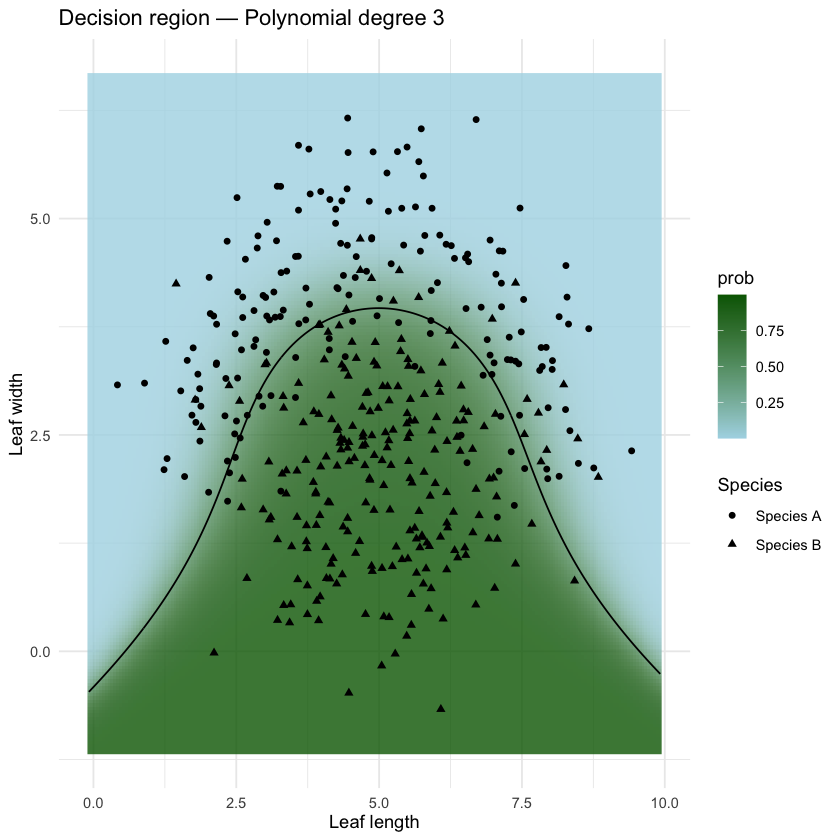

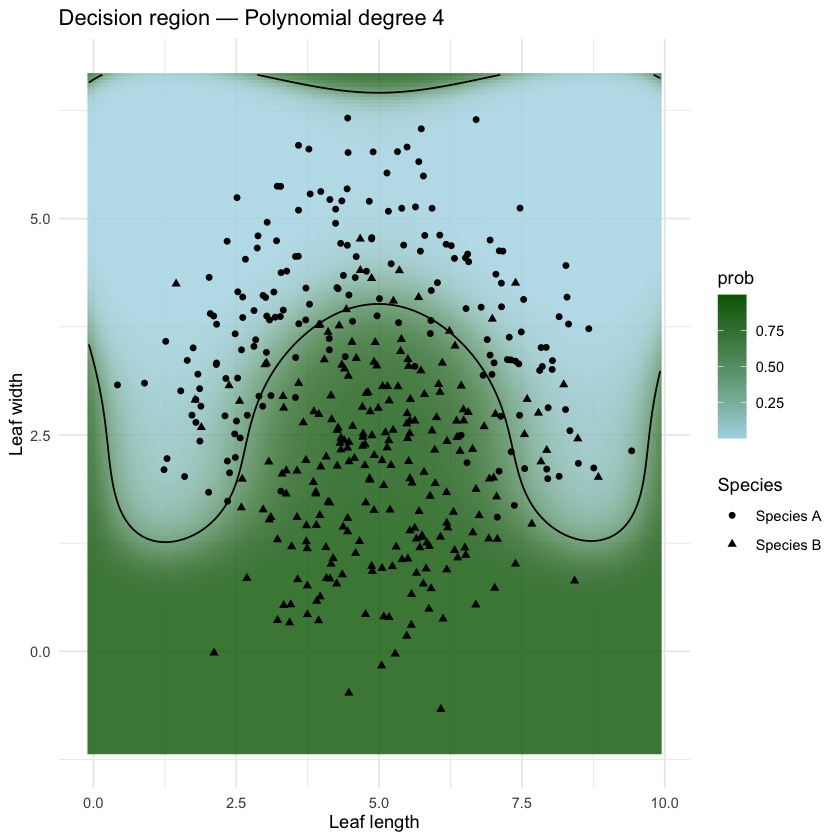

In [11]:

p1 <- ggplot(leaf, aes(x = Leaf.length, y = Leaf.width, color = Species)) +
  geom_point(size=2, alpha=0.9) +
  labs(title='Scatter: leaf length vs width', x='Leaf length', y='Leaf width') +
  theme_minimal()
print(p1)

plot(res_baseline$roc, main='ROC curves (test set)', col='black')
lines(res_poly2$roc, col='yellow')
lines(res_poly3$roc, col='green')
lines(res_poly4$roc, col='red')
legend('bottomright', legend=c(paste0('Baseline AUC=',round(res_baseline$auc,3)),
                               paste0('Poly2 AUC=',round(res_poly2$auc,3)),
                               paste0('Poly3 AUC=',round(res_poly3$auc,3)),
                               paste0('Poly4 AUC=',round(res_poly4$auc,3))),
       col=c('black','yellow','green','red'), lwd=2)

x_seq <- seq(min(leaf$Leaf.length)-0.5, max(leaf$Leaf.length)+0.5, length.out=200)
y_seq <- seq(min(leaf$Leaf.width)-0.5, max(leaf$Leaf.width)+0.5, length.out=200)
grid <- expand.grid(Leaf.length = x_seq, Leaf.width = y_seq)

pred_and_plot <- function(fit, title){
  probs <- predict(fit, newdata = grid, type='response')
  grid$prob <- probs
  grid$pred <- factor(ifelse(probs >= 0.5, levels(leaf$Species)[2], levels(leaf$Species)[1]), levels = levels(leaf$Species))
  p <- ggplot() +
    geom_raster(data = grid, aes(x = Leaf.length, y = Leaf.width, fill = prob), alpha = 0.8) +
    geom_contour(data = grid, aes(x = Leaf.length, y = Leaf.width, z = prob), breaks = 0.5, color='black') +
    geom_point(data = leaf, aes(x = Leaf.length, y = Leaf.width, shape = Species), size = 1.6) +
    labs(title = title, x = 'Leaf length', y = 'Leaf width') +
    scale_fill_gradient(low = "lightblue", high = "darkgreen") +
    theme_minimal()
  print(p)
}

pred_and_plot(model_baseline, 'Decision region — Baseline (linear)')
pred_and_plot(model_poly2, 'Decision region — Polynomial degree 2')
pred_and_plot(model_poly3, 'Decision region — Polynomial degree 3')
pred_and_plot(model_poly4, 'Decision region — Polynomial degree 4')
